<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_2_9_LogReg_OI_C9_Exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mastering logistic regression: Chapter 9 Exercises

attribution: Exercises adapted from *Introduction to Modern Statistics (2e)* Chapter 9.6.
Source: [OpenIntro IMS](https://openintro-ims.netlify.app/model-logistic)

license: This work is a derivative of [Introduction to Modern Statistics (2e)](https://openintro-ims.netlify.app/) by Mine Çetinkaya-Rundel and Johanna Hardin, used under a [Creative Commons Attribution-ShareAlike 3.0 Unported (CC BY-SA 3.0 US)](https://creativecommons.org/licenses/by-sa/3.0/us/) license.

### Introduction
Logistic regression is the foundation of classification in statistics and machine learning. Unlike linear regression, which predicts continuous values, logistic regression predicts the probability of a binary outcome (Yes/No, 1/0, Success/Failure).

### Learning objectives
By the end of this notebook, you will be able to:
1. differentiate between linear and logistic regression models.
2. interpret logistic coefficients as log-odds and odds-ratios.
3. evaluate model fit using the Akaike Information Criterion (aic).
4. identify and handle multicollinearity in classification models.
5. predict probabilities using real-world datasets (Possums and the Challenger Disaster).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
import os

# Set plot style for a polished look
sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

---
## Exercise 1: Why Not linear regression?

problem statement:
Determine which of the following statements are true and false. For each statement that is false, explain why it is false.

1. In logistic regression we fit a line to model the relationship between the predictor(s) and the binary outcome.
2. In logistic regression, we expect the residuals to be even scattered on either side of zero, just like with linear regression.
3. In logistic regression, the outcome variable is binary but the predictor variable(s) can be either binary or continuous.

### Visual Intuition
Run the cell below to see what happens when we try to fit a straight line (linear regression) to binary data compared to a Logistic curve.

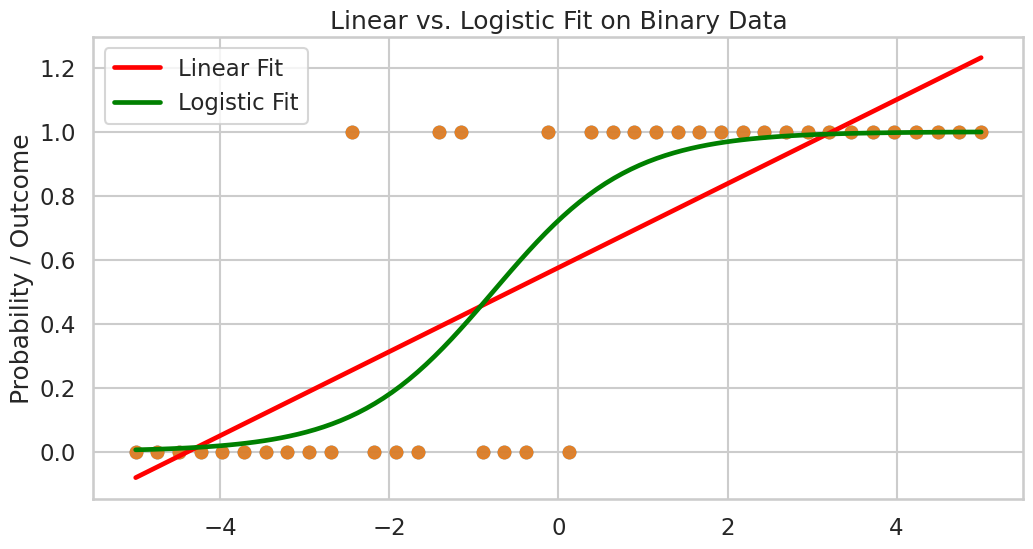

In [2]:
# Generate synthetic binary data
np.random.seed(42)
x = np.linspace(-5, 5, 40)
y = (1 / (1 + np.exp(-x)) > np.random.rand(40)).astype(int)

fig, ax = plt.subplots()
sns.regplot(x=x, y=y, logistic=False, ci=None, line_kws={'color':'red', 'label':'Linear Fit'}, ax=ax)
sns.regplot(x=x, y=y, logistic=True, ci=None, line_kws={'color':'green', 'label':'Logistic Fit'}, ax=ax)

ax.set_title("Linear vs. Logistic Fit on Binary Data")
ax.set_ylabel("Probability / Outcome")
ax.legend()
plt.show()

---
## Exercise 2: logistic regression Fact Checking

problem statement:
Review the following scenarios. Which of these properties are inherent to the logistic model?

1. linearity of probability: Does a fixed increase in $X$ always result in the same increase in predicted probability?
2. constraint: Can the model predict a probability of 1.2 or -0.2?
3. independence: Does the binary nature of the outcome mean we can ignore the assumption of independent observations?
4. model selection: Why do we use aic instead of $R^2$?

---
## Exercise 3: Possum Classification & multicollinearity

We use data from 104 brushtail possums to differentiate between those from victoria (`pop=1`) and other regions (`pop=0`).

student task:
1. Load the data.
2. Inspect the correlation between physical measurements (`head_l`, `skull_w`, `total_l`, `tail_l`).
3. Fit a "Full" model and a "Reduced" model (removing `head_l`).
4. Observe how the other coefficients change. Why does this happen?

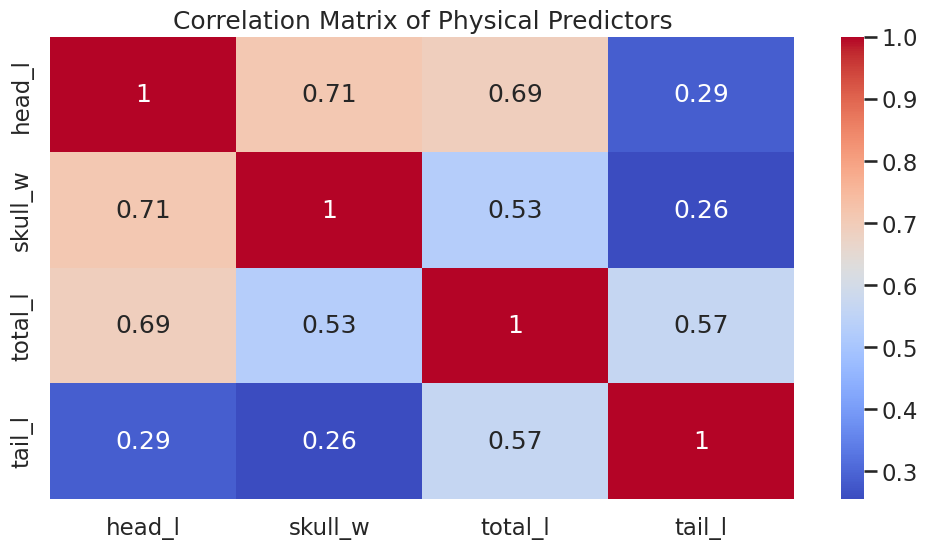

In [3]:
# 1. Load data
if not os.path.exists('possum.csv'):
    !curl -L -o possum.csv https://www.openintro.org/data/csv/possum.csv

possum = pd.read_csv('possum.csv')
possum['pop_binary'] = (possum['pop'] == 'Vic').astype(int)
possum['sex_binary'] = (possum['sex'] == 'm').astype(int)

# 2. Check for Multicollinearity
predictors = ['head_l', 'skull_w', 'total_l', 'tail_l']
corr = possum[predictors].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Physical Predictors")
plt.show()

In [4]:
# 3. Fit Models
full_model = smf.logit('pop_binary ~ sex_binary + head_l + skull_w + total_l + tail_l', data=possum).fit(disp=0)
reduced_model = smf.logit('pop_binary ~ sex_binary + skull_w + total_l + tail_l', data=possum).fit(disp=0)

print("Full Model AIC:", full_model.aic)
print("Reduced Model AIC:", reduced_model.aic)
print("\nLook at the 'skull_w' coefficient in both summaries below.")

Full Model AIC: 84.15534211970345
Reduced Model AIC: 83.51590682198784

Look at the 'skull_w' coefficient in both summaries below.


---
## Exercise 4 & 6: The Challenger Disaster

One of the most famous applications of logistic regression is the analysis of the 1986 Challenger shuttle disaster. Engineers were concerned that O-ring seals would fail at low temperatures.

the model:
$$\log\left( \frac{p}{1 - p} \right) = 11.6630 - 0.2162 \times \text{temperature}$$

student task:
1. Reconstruct the dataset from the mission summaries.
2. Visualize the probability curve.
3. Calculate the probability of failure at 31°f (the temperature on the morning of the launch).

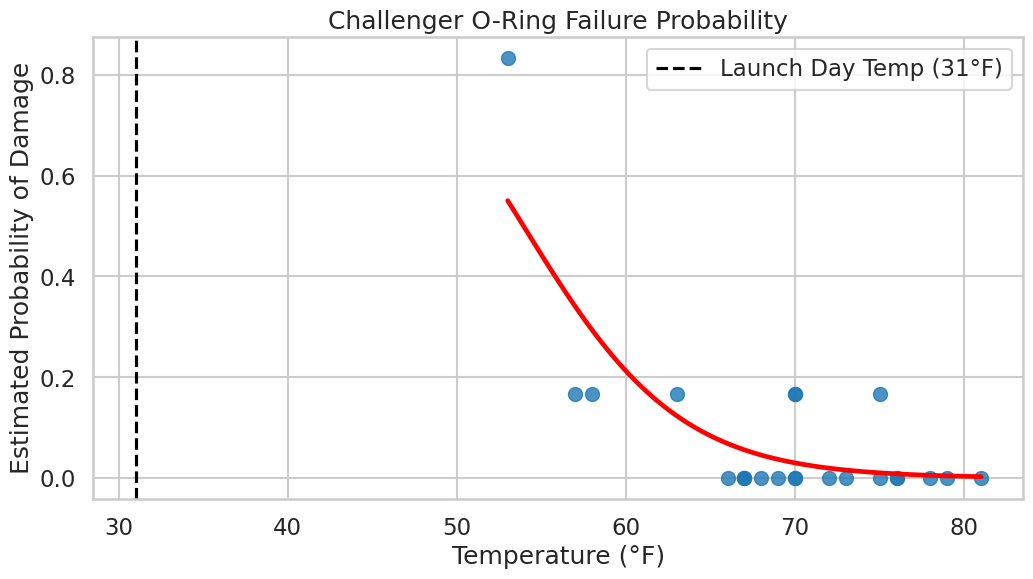

In [5]:
# Reconstructing the mission data
orings = pd.DataFrame({
    'temp': [53, 57, 58, 63, 66, 67, 67, 67, 68, 69, 70, 70, 70, 70, 72, 73, 75, 75, 76, 76, 78, 79, 81],
    'damage': [5, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
})

# Visualize with the 31°F 'Danger Zone'
sns.regplot(x='temp', y=orings['damage']/6, data=orings, logistic=True, ci=None, 
            scatter_kws={'s':100}, line_kws={'color':'red'})
plt.axvline(31, color='black', linestyle='--', label='Launch Day Temp (31°F)')
plt.title("Challenger O-Ring Failure Probability")
plt.xlabel("Temperature (°F)")
plt.ylabel("Estimated Probability of Damage")
plt.legend()
plt.show()

---
## Exercise 7 & 8: Spam Filtering & Stepwise Selection

In large-scale systems, we often have dozens of predictors. We use backward elimination to simplify the model, removing variables that don't improve the aic.

key concept: the odds ratio
If the coefficient for `winner` is 1.63, the odds ratio is $e^{1.63} \approx 5.10$. 
This means an email containing the word "winner" is 5.1 times more likely to be spam than one without it, holding all other factors constant.

---
## Exercise 10: The Data Scientist's Dilemma

If different criteria (aic, p-values, accuracy) suggest different models, how do you decide?

Consider the cost of error:
- spam filter: Is it worse to let spam into the inbox (false negative) or put a job offer in the spam folder (false positive)?
- medical screening: Is it worse to miss a disease (false negative) or cause unnecessary stress with a false alarm (false positive)?

# Solutions Appendix

### Exercise 1 Answers
1. false. We fit a logistic (s-shaped) curve. Linear regression fits a line, but it can predict probabilities less than 0 or greater than 1.
2. false. Residuals in logistic regression are not expected to be normally distributed or evenly scattered because the outcome is constrained to 0 and 1.
3. true. Predictors can be any type; only the outcome must be binary.

### Exercise 2 Answers
1. false. The change in probability depends on where you are on the curve (steeper in the middle, flatter at the ends).
2. true. The logistic function $\frac{1}{1 + e^{-z}}$ is mathematically bounded between 0 and 1.
3. false. Independence of observations is a core assumption for valid inference.
4. fact: aic is preferred because it balances goodness-of-fit with model simplicity (parsimony), whereas $R^2$ is not well-defined for logistic models.

### Exercise 3 & 9 Answers
- multicollinearity: When `head_l` is removed, the coefficient for `skull_w` becomes more significant. This is because head length and skull width are highly correlated; they are "fighting" to explain the same variance.
- best model: The model with the lowest aic is generally preferred. In this case, removing `head_l` lowered the aic, suggesting it was redundant.

### Exercise 4 & 6 Answers
- challenger prediction: At 31°F, the log-odds are $11.6630 - 0.2162(31) = 4.96$. 
- probability: $\frac{e^{4.96}}{1 + e^{4.96}} \approx 0.993$.
- conclusion: The model predicts a 99.3% chance of damage at the launch temperature. The disaster was statistically predictable.

### Exercise 5 & 8 Answers
- equation: $\text{logit}(p) = \beta_0 + \beta_1X_1 + \dots + \beta_kX_k$
- probability conversion: To get probability from log-odds ($L$), use $p = \frac{\exp(L)}{1 + \exp(L)}$.

### Exercise 7 Answers
- stepwise selection: We drop the variable that results in the lowest aic for the next step. In Step 1, dropping `exclaim_subj` improved the model the most. In Step 3, no further drops decreased the aic, so we stopped.